In [14]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update(
    {
        "font.family": "Courier New",
        "font.size": 22,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 22,
        "figure.titlesize": 22,
    }
)
plt.rcParams["lines.markeredgewidth"] = 0.5
plt.rcParams["lines.markeredgecolor"] = "black"

# Get dirs

In [15]:
root_dir = os.getcwd()
logs_dir = os.path.join(root_dir, "logs")
unet_model_dir = os.path.join(logs_dir, "unet")

def get_csv_file_path(path=str):
    if path.endswith(".csv") and os.path.isfile(path):
        csv_file_path = path
    else:
        # tìm version mới nhất trong folder
        version_dirs = glob.glob(os.path.join(path, "version_*"))
        if not version_dirs:
            raise FileNotFoundError(f"No version_x folders found in {path}")
        latest_version = max(version_dirs, key=os.path.getmtime)
        csv_file_path = os.path.join(latest_version, "metrics.csv")
    return csv_file_path

latest_version_unet = "version_12"
metrics_csv_unet = os.path.join(unet_model_dir, latest_version_unet, "metrics.csv")
print(metrics_csv_unet)
unet_csv_file_path = get_csv_file_path(metrics_csv_unet)
seg_model_dir = os.path.join(logs_dir, "segformer") 
segformer_csv_file_path = get_csv_file_path(seg_model_dir)

f:\Temp\Thang\Paper-2025-MurineCyto-Det\logs\unet\version_12\metrics.csv


In [16]:
unet_csv_file_path, segformer_csv_file_path

('f:\\Temp\\Thang\\Paper-2025-MurineCyto-Det\\logs\\unet\\version_12\\metrics.csv',
 'f:\\Temp\\Thang\\Paper-2025-MurineCyto-Det\\logs\\segformer\\version_2\\metrics.csv')

In [17]:
# Load data of unet model
df_unet = pd.read_csv(unet_csv_file_path)
df_unet_train = df_unet.dropna(subset=["train_loss"])
df_unet_val = df_unet.dropna(subset=["valid_loss"])
df_unet_train = df_unet_train.dropna(axis=1, how='all')
df_unet_val = df_unet_val.dropna(axis=1, how='all')
print("Metrics dataset of UNet model:")
print(df_unet_train.head(5))

# Load data of segformer model
df_segformer = pd.read_csv(segformer_csv_file_path) 
df_segformer_train = df_segformer.dropna(subset=["train_loss"])
df_segformer_val = df_segformer.dropna(subset=["valid_loss"])
df_segformer_train = df_segformer_train.dropna(axis=1, how='all')
df_segformer_val = df_segformer_val.dropna(axis=1, how='all')
print("Metrics dataset of SegFormer model:")
print(df_segformer_train.head(5))

Metrics dataset of UNet model:
   epoch  step  train_acc  train_dice  train_f1  train_gds  train_loss  \
1      0    29   0.505910    0.505910  0.505910   0.055160    0.627230   
3      1    59   0.702036    0.702036  0.702036   0.116935    0.547158   
5      2    89   0.700605    0.700605  0.700605   0.122252    0.541734   
7      3   119   0.642983    0.642983  0.642983   0.133586    0.504418   
9      4   149   0.653662    0.653662  0.653662   0.141918    0.485621   

   train_miou  train_precision  train_recall  
1    0.130253         0.505910      0.505910  
3    0.209814         0.702036      0.702036  
5    0.225159         0.700605      0.700605  
7    0.240708         0.642983      0.642983  
9    0.256320         0.653662      0.653662  
Metrics dataset of SegFormer model:
   epoch  step  train_acc  train_dice  train_f1  train_gds  train_loss  \
1      0    29   0.755642    0.755642  0.755642   0.163387    0.502819   
3      1    59   0.833101    0.833101  0.833101   0.221290

# Plot metrics curve

In [18]:
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'H', '8']
colors = plt.cm.get_cmap('tab10').colors

def plot_each_metric(dfs: dict, x_col="epoch", save_dir=None, prefix=str):
    """
    Plot each metric and compare across multiple DataFrames.

    Args:
        dfs (dict): Dictionary where keys are names and values are pandas DataFrames.
        x_col (str): Column name for the X-axis (default: 'epoch').
        save_dir (str): Directory to save figures (optional).
        prefix (str): add prefix to file name
    """
    if not dfs:
        print("No dataframes provided.")
        return

    # Get list of metric columns from the first DataFrame
    first_df = next(iter(dfs.values()))
    metric_cols = [c for c in first_df.columns if c not in ["epoch", "step"]]

    for col in metric_cols:
        fig, ax = plt.subplots(figsize=(8, 6))

        for idx, (name, df) in enumerate(dfs.items()):
            if col not in df.columns:
                print(f"⚠️ Column '{col}' not found in dataframe '{name}', skipping.")
                continue

            ax.plot(
                df[x_col], df[col],
                label=name,
                marker=markers[idx % len(markers)],
                color=colors[idx % len(colors)],
                markersize=6,
                linewidth=2,
            )

        ax.set_xlabel(x_col.capitalize())
        ax.set_ylabel(col)
        # ax.set_title(f"{col}", fontsize=12)
        ax.grid(True, which="major", linestyle="-", linewidth=0.25, alpha=0.35)
        ax.minorticks_on()
        ax.grid(True, which="minor", linestyle="-", linewidth=0.15, alpha=0.25)

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.15),
            frameon=False,
            ncol=2,
        )

        fig.tight_layout()

        # Save or show
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            file_name = f"{prefix}-{col}.pdf"
            file_path = os.path.join(save_dir, file_name)
            plt.savefig(file_path, bbox_inches="tight", dpi=300)
            print(f"✅ Saved image: {file_path}")
            plt.close(fig)  # Close after saving to avoid memory leak
        else:
            plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_14436\3976328588.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


## train dataset

In [19]:
dfs_train = {
  "unet": df_unet_train,
  "segformer": df_segformer_train
}
save_dir = os.path.join(root_dir, "figures")
plot_each_metric(dfs_train,save_dir=save_dir, prefix = "seg")

✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_acc.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_dice.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_f1.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_gds.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_loss.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_miou.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_precision.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-train_recall.pdf


## val dataset

In [20]:
dfs_val = {
  "UNet": df_unet_val,
  "Segformer": df_segformer_val
}
plot_each_metric(dfs_val, save_dir=save_dir, prefix="seg")

✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_acc.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_dice.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_f1.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_gds.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_loss.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_miou.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_precision.pdf
✅ Saved image: f:\Temp\Thang\Paper-2025-MurineCyto-Det\figures\seg-valid_recall.pdf


# Quantitative plots

## Function

In [21]:
def plot_final_metrics_bar(dfs: dict, metrics: list, prefix="valid_"):
    """
    Plot grouped bar chart comparing final values of metrics across models.

    Args:
        dfs (dict): {model_name: df_val}
        metrics (list): list of short metric names (e.g. ["acc", "dice", "miou", "gds", "loss"])
        prefix (str): either "train_" or "valid_", used to pick the right columns
    """
    results = {}

    for name, df in dfs.items():
        last_row = df.dropna().iloc[-1]
        values = []
        for m in metrics:
            col_candidates = [c for c in df.columns if c.startswith(prefix) and m in c]
            if not col_candidates:
                raise KeyError(f"Column with prefix '{prefix}' and metric '{m}' not found in DataFrame {name}")
            col = col_candidates[0]  # pick the first match
            values.append(last_row[col])
        results[name] = values

    results_df = pd.DataFrame(results, index=metrics)

    results_df_long_form = results_df.reset_index().melt(id_vars= 'index', var_name='Model', value_name='Score' )
    # plot grouped bar chart
    fig, ax = plt.subplots(figsize=(14, 8))
    ax = sns.barplot(
        data=results_df_long_form,
        x='index',
        y='Score',
        hue = 'Model',
        errorbar=None, 
        palette="viridis",
        edgecolor="darkgray",
        legend=True,
        )

    plt.xticks(rotation=30)
    plt.xlabel("")

    # Ẩn ticks ở x-axis, chỉ giữ label
    ax.tick_params(axis="x", which="both", length=10, bottom=False, top=False)
    # ax.tick_params(axis="y", which="both", length=0)

    # Thêm grid và minor grid cho y-axis
    plt.grid(
        True, which="major", axis="y", linestyle="-", linewidth=0.25, alpha=0.35
    )
    plt.minorticks_on()
    plt.grid(
        True, which="minor", axis="y", linestyle="-", linewidth=0.15, alpha=0.25
    )
    ax.set_axisbelow(True)

    for container in ax.containers:
        ax.bar_label(container=container, fmt="%.3f", label_type="edge", fontsize=20)

    plt.tight_layout()
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.1),
        fancybox = False,
        shadow=False,
        frameon=False,
        ncol=2
    )
    
    plt.tight_layout()
    plt.show()

    return results_df



## Training dataset

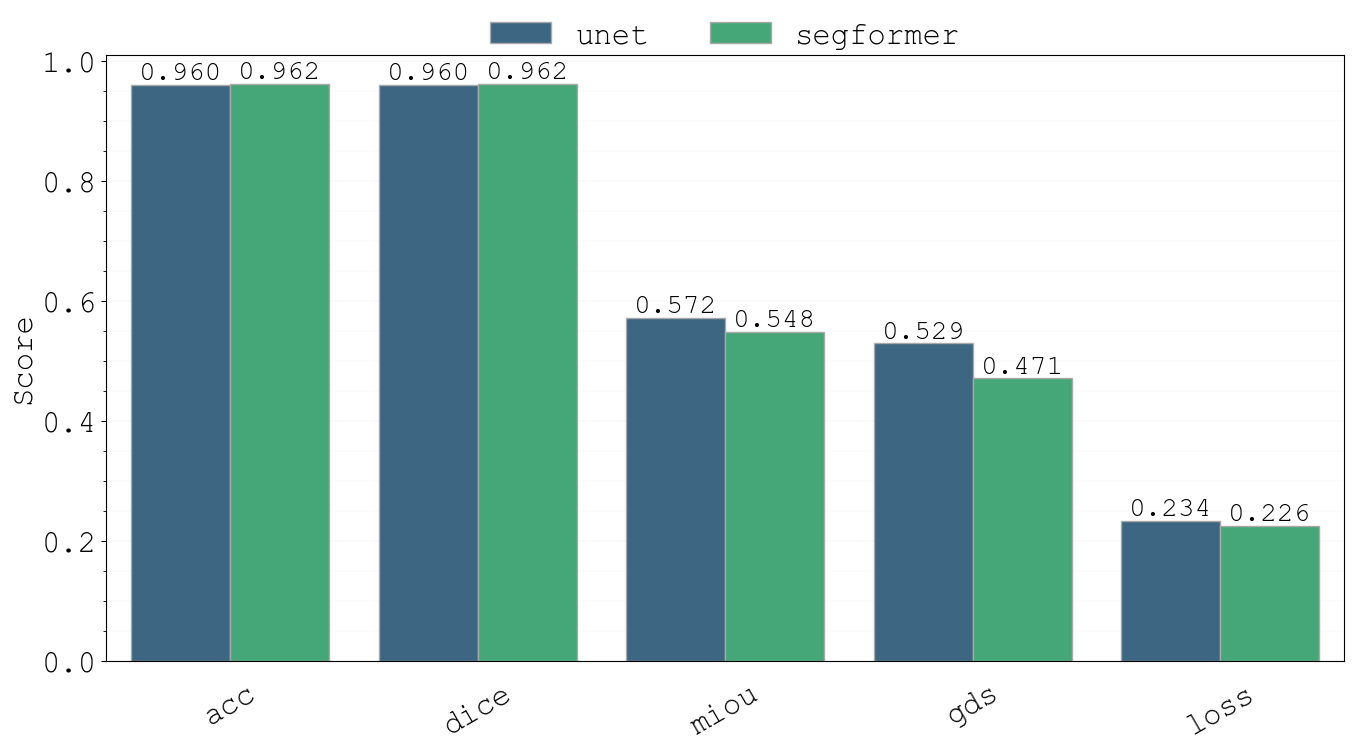

In [22]:
metrics = ["acc", "dice", "miou", "gds", "loss"]
train_results = plot_final_metrics_bar(dfs_train, metrics, prefix="train_")

## Validation

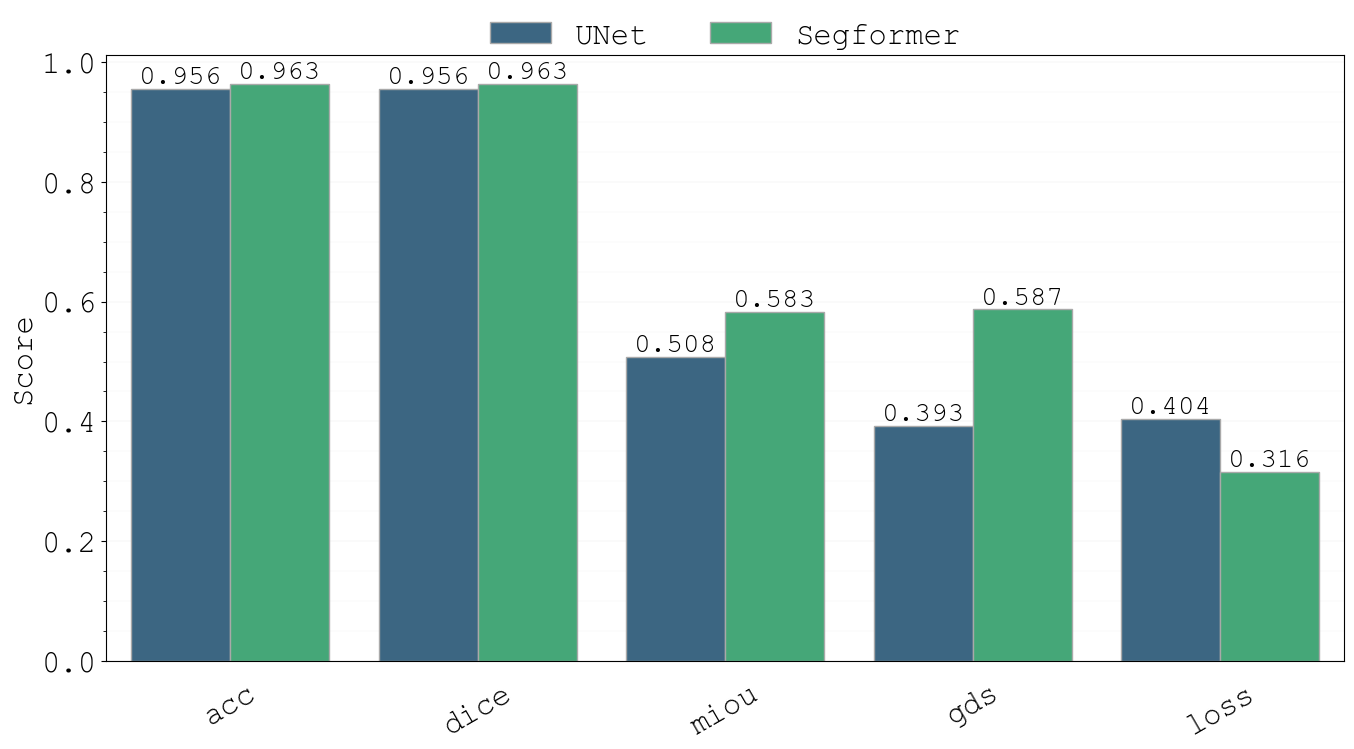

          UNet  Segformer
acc   0.955574   0.963494
dice  0.955575   0.963494
miou  0.508172   0.583463
gds   0.392785   0.586839
loss  0.404163   0.315676


In [23]:
results = plot_final_metrics_bar(dfs_val, metrics, prefix="valid_")
print(results)


# Qualitative plots

## Load models

In [24]:
import zipfile
from sklearn.model_selection import train_test_split
from huggingface_hub import hf_hub_download
from torch.utils.data import DataLoader
from seg_v1 import MurineCellModel
from seg_v1 import Dataset
from seg_v1 import get_validation_augmentation
import os
from dotenv import load_dotenv

load_dotenv()
token = os.getenv('HF_TOKEN')
# %% Dirs
root_dir = os.getcwd()
model_dir = os.path.join(root_dir, "models")
os.makedirs(model_dir, exist_ok=True)
data_zip_path = hf_hub_download(
    repo_id = "thanglexuan/murincells",
    filename = "data.zip",
    repo_type = "dataset",
    token = token
)
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
with zipfile.ZipFile(data_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)
    
images_dir = os.path.join(data_dir, "images")
masks_dir = os.path.join(data_dir, "masks")
image_ls = sorted(os.listdir(images_dir))
mask_ls = sorted(os.listdir(masks_dir))

x_train_dir, x_temp_dir, y_train_dir, y_temp_dir = train_test_split(
    image_ls, mask_ls, test_size=0.3, random_state=42
)
x_val_dir, x_test_dir, y_val_dir, y_test_dir = train_test_split(
    x_temp_dir, y_temp_dir, test_size=0.5, random_state=42
)
print("train size:{}".format(len(x_train_dir)))
print("val size:{}".format(len(x_val_dir)))
print("test size:{}".format(len(x_test_dir)))

# %% Split dataset
test_dataset = Dataset(
    data_dir=data_dir,
    images_dir=x_test_dir,
    masks_dir=y_test_dir,
    augmentation=get_validation_augmentation(),
)

# Change to > 0 if not on Windows machine
BATCH_SIZE = 8
NUM_WORKERS = 0
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

AttributeError: partially initialized module 'torch' has no attribute 'fx' (most likely due to a circular import)

In [ ]:
model_dir = os.path.join(root_dir, "models")
unet_ckpt_path = os.path.join(model_dir, "unet.ckpt")
segformer_ckpt_path = os.path.join(model_dir, "segformer.ckpt")
NUM_CLASSES = len(test_dataset.CLASSES)

unet_loaded_model = MurineCellModel.load_from_checkpoint(
    unet_ckpt_path,
    arch='Unet',
    encoder_name="resnet34",
    in_channels=3,
    num_classes=NUM_CLASSES
)
segformer_loaded_model = MurineCellModel.load_from_checkpoint(
    segformer_ckpt_path, 
    arch='Segformer',
    encoder_name="resnet34",
    in_channels=3,
    num_classes=NUM_CLASSES
)

f:\Temp\Thang\Paper-2025-Dataset\.pixi\envs\default\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


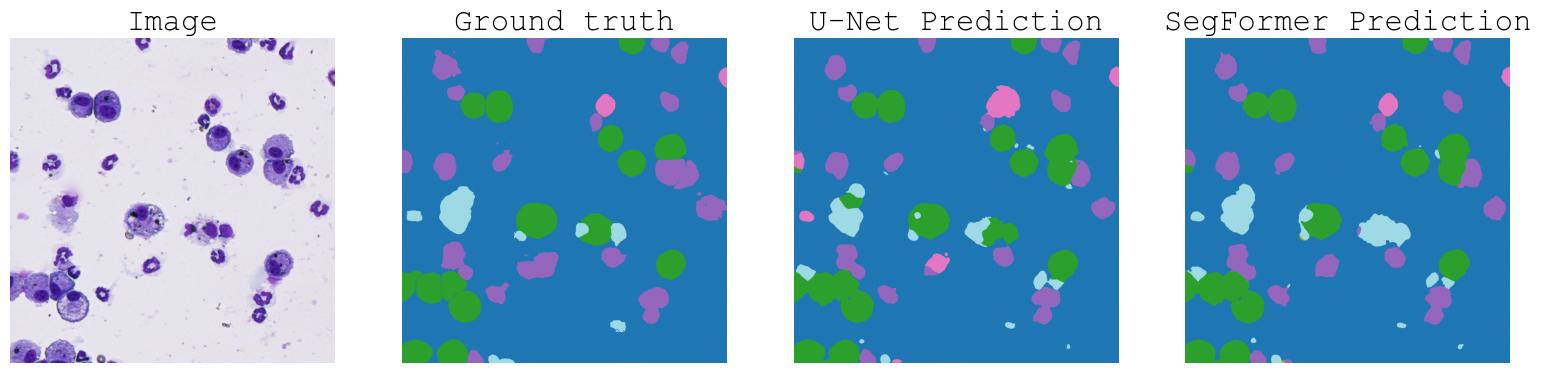

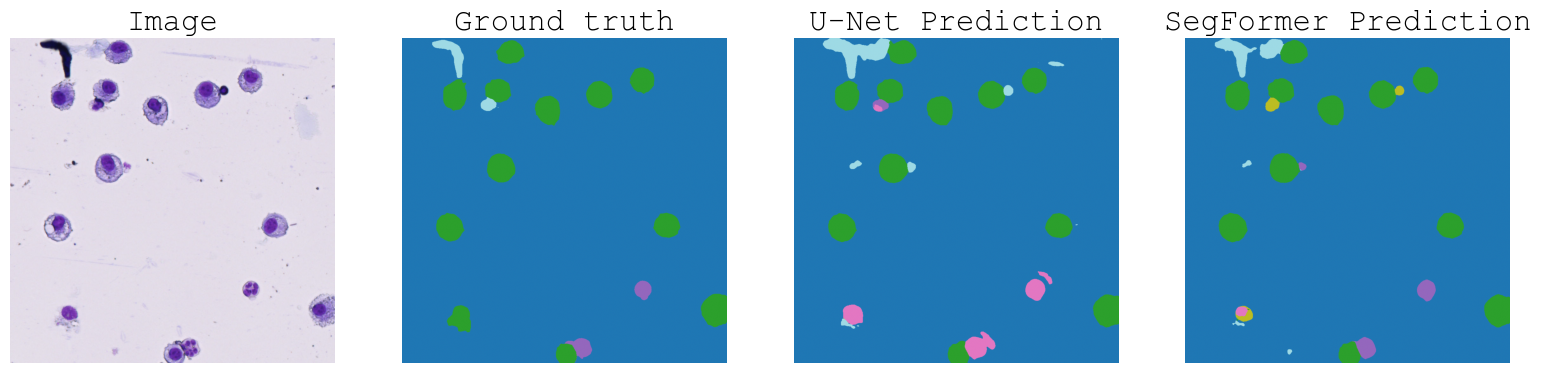

In [ ]:
from helpers import visualize, predict_and_plot, predict_and_plot_multi

models = {
    "U-Net": unet_loaded_model,
    "SegFormer": segformer_loaded_model,
}

predict_and_plot_multi(
    models=models,
    dataloader=test_loader,
    n_samples=3,
    save_dir=save_dir,
    prefix="seg-"
)


# Confusion matrix

In [ ]:
import numpy as np
def visualize_batch(images, masks, class_names, n=4):
    """
    Show n samples from a batch with their image and mask.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    
    batch_size = images.shape[0]
    n = min(n, batch_size)

    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = np.transpose(images[i], (1,2,0))

        # --- Fix: scale if float data is not in [0,1] ---
        if img.dtype in (np.float32, np.float64):
            img = img / 255.0 if img.max() > 1.0 else img

        mask = masks[i]

        axes[i][0].imshow(img)
        axes[i][0].set_title("Image")
        axes[i][0].axis("off")

        im = axes[i][1].imshow(mask, cmap="tab20")
        axes[i][1].set_title("Mask")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names, ignore_index=0, normalize=True, cmap="Blues"):
    """
    Plot confusion matrix for segmentation masks (per-pixel).
    
    Args:
        y_true: (H, W) ground truth mask (integers: class indices)
        y_pred: (H, W) predicted mask (integers: class indices)
        class_names: list of class names
        normalize: if True, normalize rows to percentages
    """
    # Flatten thành vector pixel
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # mask out background
    mask = y_true != ignore_index
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    labels = [i for i in range(len(class_names)) if i != ignore_index]
    display_names = [class_names[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        with np.errstate(all='ignore'):  # ignore divide by zero warnings
            cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        cm = np.nan_to_num(cm)  # replace NaN (rows with 0 samples) with 0

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap=cmap,
        xticklabels=display_names,
        yticklabels=display_names,
        annot_kws={"size": 20},  # size of numbers inside cells
        cbar=False,
    )
    # plt.xlabel("Predicted", fontsize=20)
    # plt.ylabel("Ground Truth", fontsize=20)
    # plt.title("Confusion Matrix (per-pixel, no Background)", fontsize=16)
    plt.xticks(fontsize=20, rotation=30)
    plt.yticks(fontsize=20, rotation=0)
    plt.show()



Found Lymphocyte in batch 0, shape: torch.Size([8, 1024, 1024])
First sample index in batch with Lymphocyte: 6
6


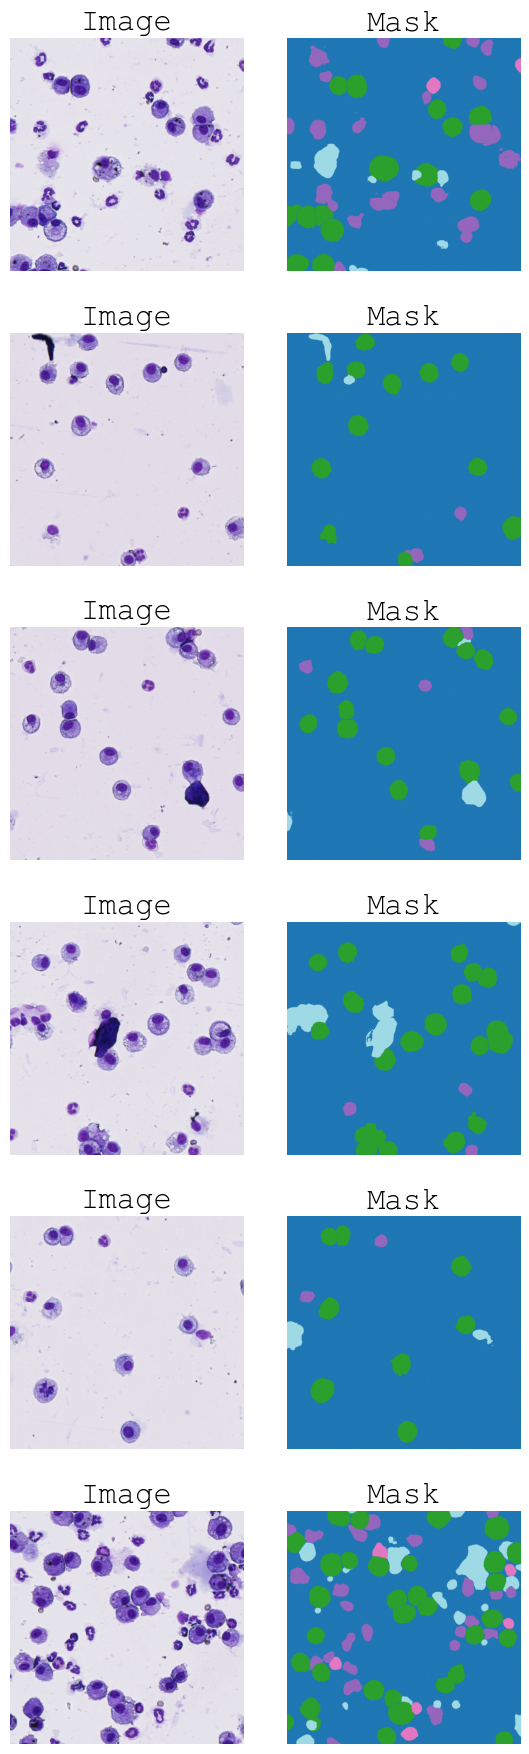

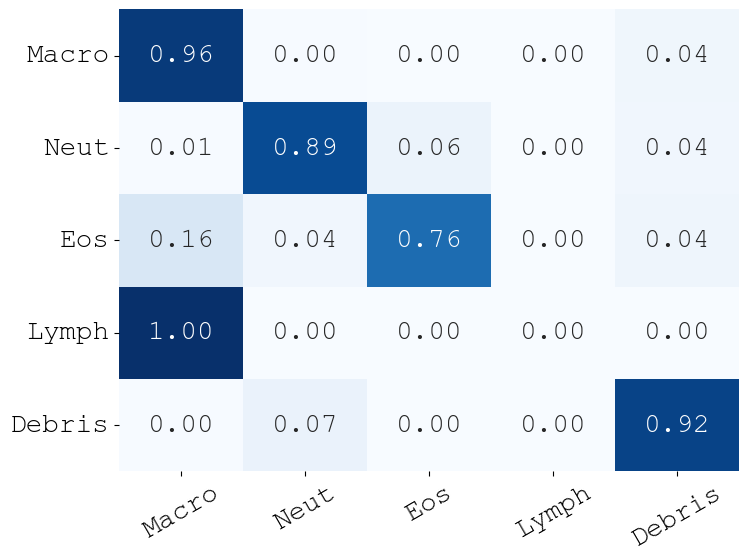

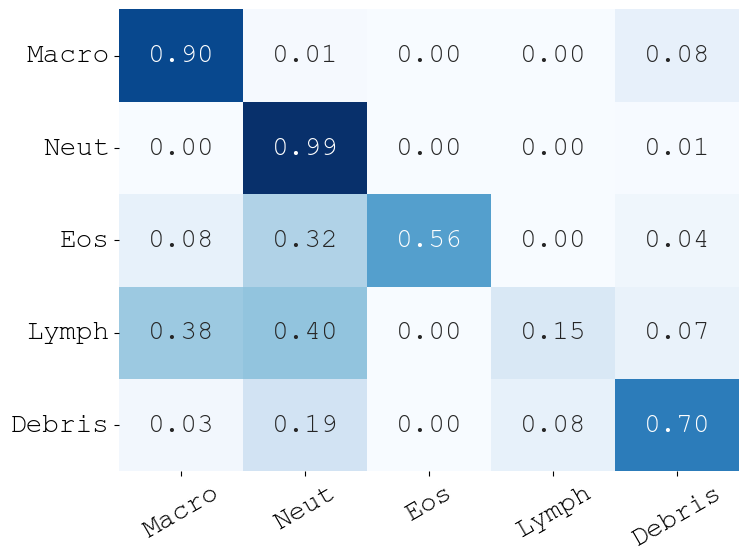

In [ ]:
# # lấy 1 batch từ test_loader
CLASSES = [
    "Background",
    "Macrophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris"
]
for i, (images, masks) in enumerate(test_loader):
    # check if this batch contains any pixels == 4 (Lymphocyte class)
    if (masks == 4).any():
        print(f"Found Lymphocyte in batch {i}, shape: {masks.shape}")
        idx = (masks == 4).nonzero(as_tuple=True)[0][0].item()
        print(f"First sample index in batch with Lymphocyte: {idx}")
        # take one sample to visualize or test
        image = images[idx]
        mask  = masks[idx]
        break
# images, masks = next(iter(test_loader))
print(idx)
visualize_batch(images, masks, CLASSES, n=idx)



In [ ]:
# predict
with torch.no_grad():
    logits = unet_loaded_model(images.to("cuda"))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

# lấy ảnh đầu tiên trong batch
y_true = masks[idx].numpy()
y_pred = preds[idx]


SHORT_CLASSES = [
    "BG",      # Background
    "Macro",   # Macrophage/Monocyte
    "Neut",    # Neutrophil
    "Eos",     # Eosinophil
    "Lymph",   # Lymphocyte
    "Debris"   # Unknown cell/Debris
]
plot_confusion_matrix(y_true, y_pred, SHORT_CLASSES, ignore_index=0, normalize=True)


# predict
with torch.no_grad():
    logits = segformer_loaded_model(images.to("cuda"))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

# lấy ảnh đầu tiên trong batch
y_true_2 = masks[idx].numpy()
y_pred_2 = preds[idx]

plot_confusion_matrix(y_true_2, y_pred_2, SHORT_CLASSES, ignore_index=0, normalize=True)

# END